In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('data.xlsx')
df = df.fillna(method='ffill')
feats = ['time_adj_S2K_items_1to7_percentage_followup',
'time_adj_S2K_item_8_percentage_followup',
'time_adj_S2K_item_9_percentage_followup',
'time_adj_S2K_item_10_percentage_followup',
'time_adj_S2K_items_11to14_percentage_followup',
'time_adj_S2K_item_15_percentage_followup',
'time_adj_S2K_item_16_percentage_followup',
'time_adj_S2K_item_17_percentage_followup',
'time_adj_S2K_items_18to19_percentage_followup',
'time_adj_S2K_item_20_percentage_followup',
'time_adj_S2K_item_21_percentage_followup',
'time_adj_S2K_item_22_percentage_followup',
'time_adj_S2K_item_23_percentage_followup',
'time_adj_S2K_item_24_percentage_followup',
]

scaler = MinMaxScaler()

features = df.loc[:, feats]
features = features.apply(lambda x: x / 100)
targets = df.loc[:, ['Adj_mean_PGA_cum_per_fu','Adj_mean_GC_intake_cum_per_fu']]
targets = pd.DataFrame(scaler.fit_transform(targets))

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, shuffle=True, random_state=42)

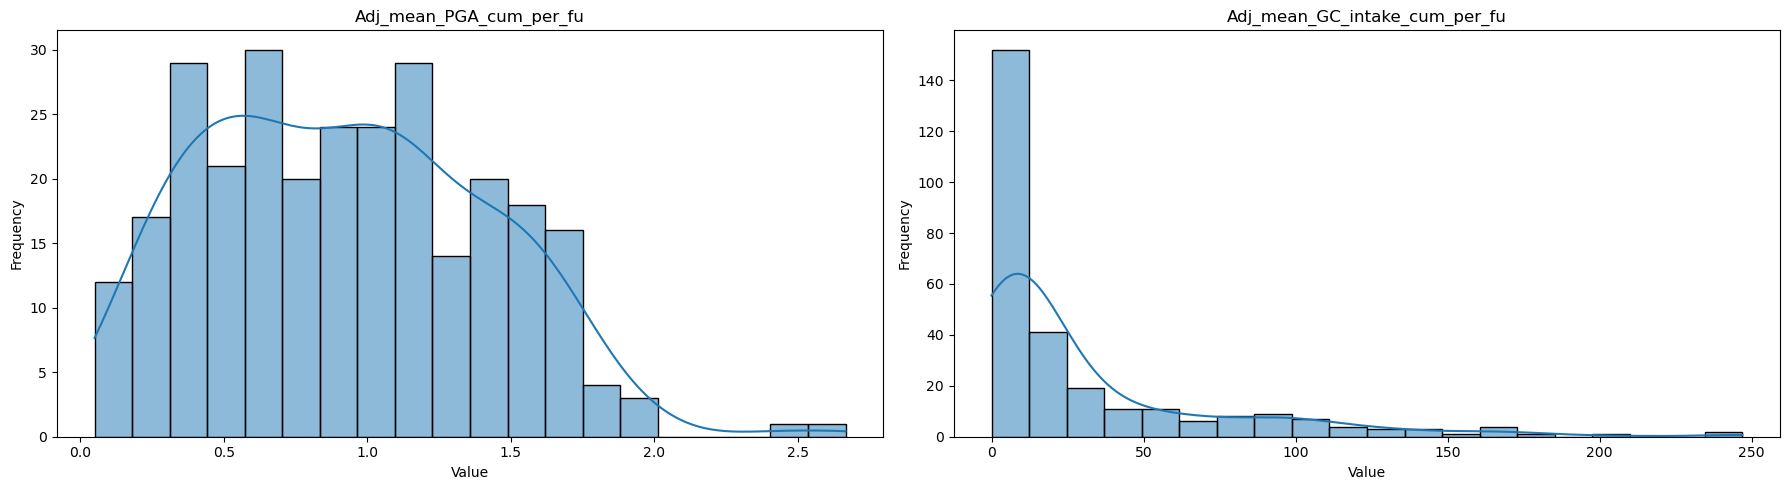

In [ ]:
plt.figure(figsize=(18, 5))


for i, col in enumerate(y_train.columns):
    plt.subplot(1, len(y_train.columns), i+1)
    sns.histplot(y_train.iloc[:,i], bins=20, kde=True) 
    plt.title(col)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [4]:
pga_rf = RandomForestRegressor(random_state=42)
gc_rf = RandomForestRegressor(random_state=42)

regressors = [pga_rf, gc_rf]
reg_names = ['PGA', 'GC']

def regressions():
    losses = {}
    importances = {}
    for i, name in zip(range(len(regressors)), reg_names):
        regressors[i].fit(X_train, y_train[i])
        preds = regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[i], preds)
        importances[name] = regressors[i].feature_importances_
        losses[name] = loss

    return losses, importances

classification = regressions()
print(f'PGA loss: {classification[0]["PGA"]}\nGC loss: {classification[0]["GC"]}')

PGA loss: 0.011169469351261655
GC loss: 0.022835979431017926


<Axes: xlabel='importance', ylabel='item'>

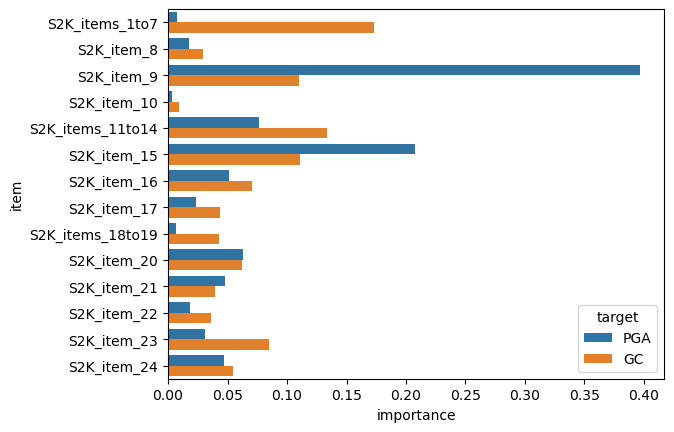

In [5]:
import re

importances_df = pd.DataFrame(regressions()[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))

sns.barplot(melted,x='importance',y='item', hue='target')


PGA loss: 0.008456196732743665
GC loss: 0.022364196185142234


<Axes: xlabel='importance', ylabel='item'>

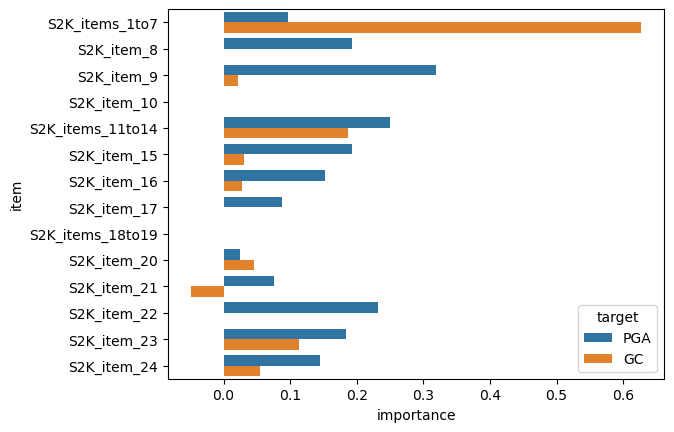

In [6]:
from sklearn.linear_model import Lasso

pga_lasso = Lasso(alpha=0.001, random_state=42)
gc_lasso = Lasso(alpha=0.001, random_state=42)

lasso_regressors = [pga_lasso, gc_lasso]
lasso_reg_names = ['PGA', 'GC']

def lasso():
    losses = {}
    coefs = {}
    for i, name in zip(range(len(lasso_regressors)), lasso_reg_names):
        lasso_regressors[i].fit(X_train, y_train[i])
        preds = lasso_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[i], preds)
        coefs[name] = lasso_regressors[i].coef_
        losses[name] = loss

    return losses, coefs

classification = lasso()
print(f'PGA loss: {classification[0]["PGA"]}\nGC loss: {classification[0]["GC"]}')


importances_df = pd.DataFrame(lasso()[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))

sns.barplot(melted,x='importance',y='item', hue='target')


PGA loss: 0.009726481084090475
GC loss: 0.02416547335664999


<Axes: xlabel='importance', ylabel='item'>

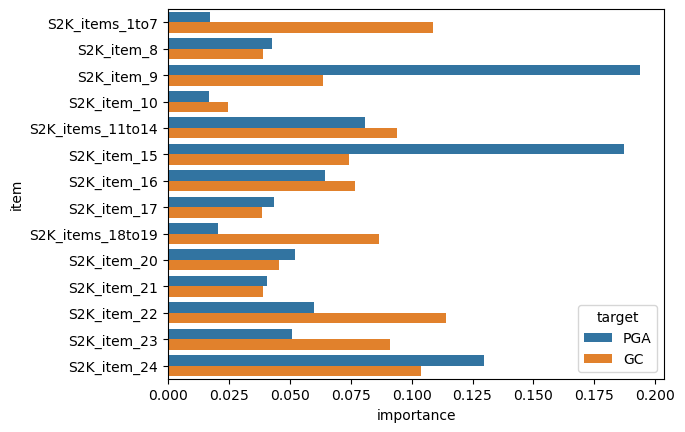

In [7]:
import xgboost

pga_xgb = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gc_xgb = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

xgb_regressors = [pga_xgb, gc_xgb]
xgb_reg_names = ['PGA', 'GC']


def xgb():
    losses = {}
    imps = {}
    for i, name in zip(range(len(xgb_regressors)), xgb_reg_names):
        xgb_regressors[i].fit(X_train, y_train[i])
        preds = xgb_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[i], preds)
        imps[name] = xgb_regressors[i].feature_importances_
        losses[name] = loss

    return losses, imps

classification = xgb()
print(f'PGA loss: {classification[0]["PGA"]}\nGC loss: {classification[0]["GC"]}')


importances_df = pd.DataFrame(xgb()[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))

sns.barplot(melted,x='importance',y='item', hue='target')


PGA loss: 0.00835845261774054
GC loss: 0.021786733465824326


<Axes: xlabel='importance', ylabel='item'>

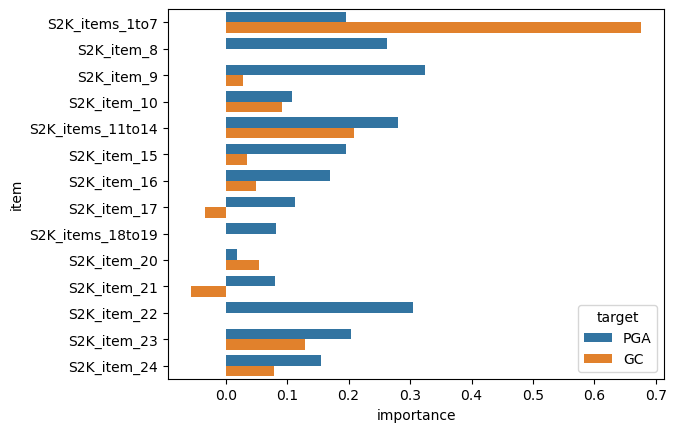

In [12]:
from sklearn.linear_model import ElasticNet

elastic_pga = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42)
elastic_gc = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42)


elastic_regressors = [elastic_pga, elastic_gc]
elastic_reg_names = ['PGA', 'GC']


def elastic():
    losses = {}
    imps = {}
    for i, name in zip(range(len(elastic_regressors)), elastic_reg_names):
        elastic_regressors[i].fit(X_train, y_train[i])
        preds = elastic_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[i], preds)
        imps[name] = elastic_regressors[i].coef_
        losses[name] = loss

    return losses, imps

classification = elastic()
print(f'PGA loss: {classification[0]["PGA"]}\nGC loss: {classification[0]["GC"]}')

importances_df = pd.DataFrame(elastic()[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))

sns.barplot(melted,x='importance',y='item', hue='target')

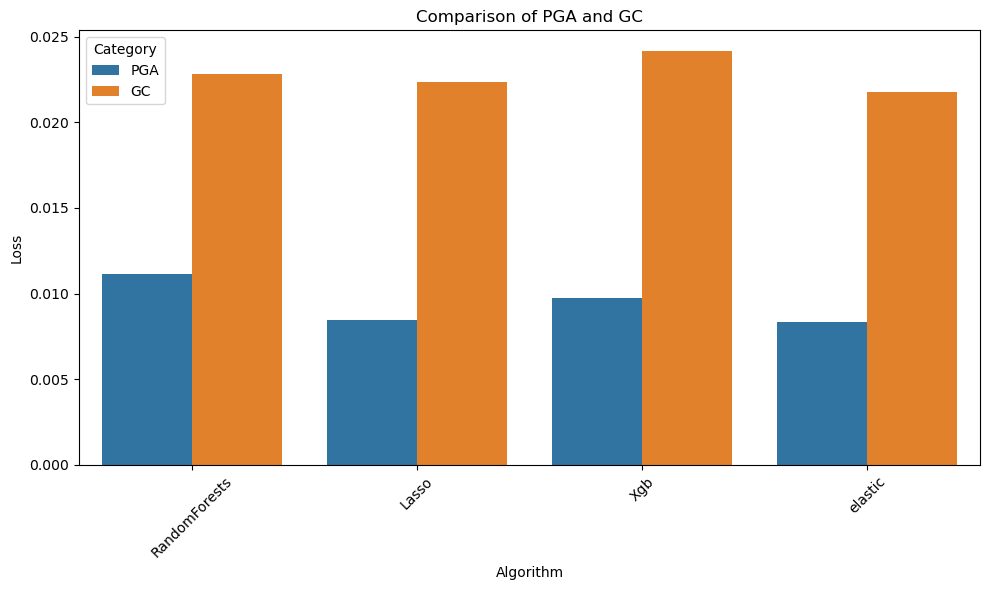

In [15]:
ovr_df = pd.DataFrame([regressions()[0], lasso()[0], xgb()[0], elastic()[0]],index=['RandomForests', 'Lasso', 'Xgb', 'elastic'])
long_df = ovr_df.reset_index().melt(id_vars='index', value_vars=['PGA', 'GC'], 
                                    var_name='Category', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(data=long_df, x='index', y='Value', hue='Category')

plt.xlabel('Algorithm')
plt.ylabel('Loss')
plt.title('Comparison of PGA and GC')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

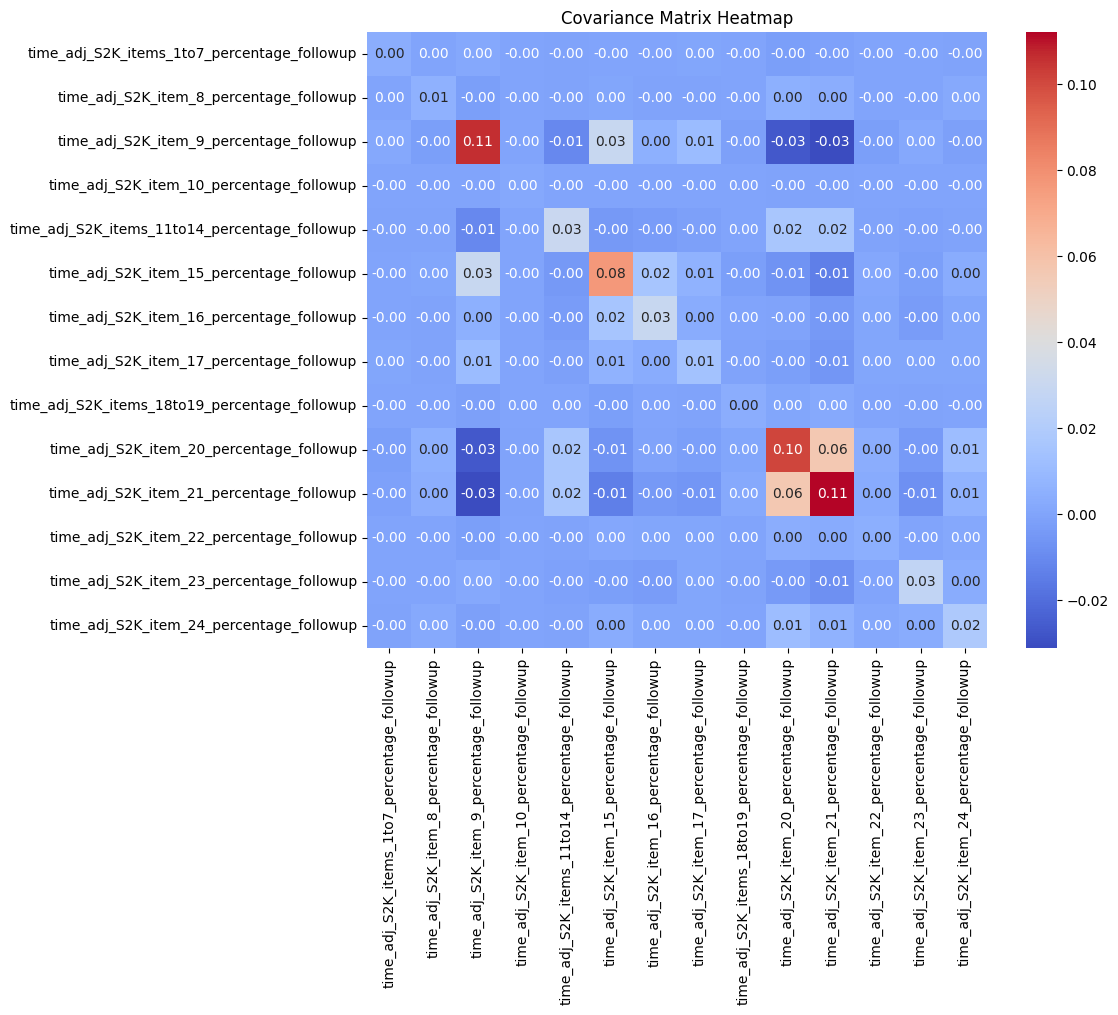

In [18]:
cov_matrix = np.cov(features, rowvar=False) 


plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=features.columns, yticklabels=features.columns)
plt.title("Covariance Matrix Heatmap")
plt.show()
